# Ch 5 — 指數函數求導 (Derivatives of Exponentials)

> 來自 3Blue1Brown《微積分的本質》第五章

> 這一章回答兩個問題：
> 1. $a^x$ 的導數長什麼樣？為什麼是 $a^x \cdot \ln(a)$？
> 2. 為什麼數學家偏愛 $e \approx 2.71828$？因為它是讓「**斜率 = 高度**」這件事成立的那個唯一底數。

本筆記涵蓋：
1. 從定義硬算 $2^x$ 的導數
2. 發現「$a^x$ 的導數 = $a^x$ × 某個常數」
3. 用數值方法**找出** $e$
4. 為什麼 $\frac{d}{dx} e^x = e^x$
5. 鏈式法則延伸：$\frac{d}{dx} e^{f(x)}$
6. 視覺化「斜率 = 高度」
7. 連到深度學習：sigmoid、softmax、為什麼 $e$ 無所不在
8. 練習 + 總結

## Part 0：環境設定

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def central_diff(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)


def setup_ax(ax, title=""):
    ax.grid(True, linewidth=0.3)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.5)
    if title:
        ax.set_title(title)
    return ax


print("Helpers loaded ✓")

Helpers loaded ✓


## Part 1：從定義硬算 $2^x$ 的導數

### 動機

$\frac{d}{dx} x^2 = 2x$ 這件事我們已經習慣了。但 $\frac{d}{dx} 2^x$ 呢？變數從**底**跑到**指數**，公式根本不一樣。

### 從定義出發

$$\frac{d}{dx} 2^x = \lim_{h \to 0} \frac{2^{x+h} - 2^x}{h} = \lim_{h \to 0} \frac{2^x \cdot 2^h - 2^x}{h} = 2^x \cdot \lim_{h \to 0} \frac{2^h - 1}{h}$$

注意這個關鍵分解：

$$\frac{d}{dx} 2^x = 2^x \cdot \underbrace{\lim_{h \to 0} \frac{2^h - 1}{h}}_{\text{某個常數}}$$

也就是說，**$2^x$ 的導數 = $2^x$ 本身 乘上一個常數**！這個常數和 $x$ 完全無關，只跟「底是 2」這件事有關。我們先用數值算它出來。

In [2]:
# === 實驗 1：找出 2^x 那個神秘常數 ===
# 在 x = 0 處算 2^x 的導數，因為 2^0 = 1，導數值就直接等於那個常數
def f2(x): return 2.0 ** x

const_2 = central_diff(f2, 0.0)
print(f"d/dx (2^x) 在 x=0 = {const_2:.10f}")
print(f"ln(2)             = {np.log(2):.10f}  ← 完美吻合！")

print()
# 在不同 x 驗證：d/dx (2^x) = 2^x · ln 2
for x in [0.0, 1.0, 2.0, -1.0]:
    numeric = central_diff(f2, x)
    formula = 2**x * np.log(2)
    print(f"  x={x:>4}:  數值 d/dx(2^x) = {numeric:.6f}  |  2^x·ln(2) = {formula:.6f}")

d/dx (2^x) 在 x=0 = 0.6931471806
ln(2)             = 0.6931471806  ← 完美吻合！

  x= 0.0:  數值 d/dx(2^x) = 0.693147  |  2^x·ln(2) = 0.693147
  x= 1.0:  數值 d/dx(2^x) = 1.386294  |  2^x·ln(2) = 1.386294
  x= 2.0:  數值 d/dx(2^x) = 2.772589  |  2^x·ln(2) = 2.772589
  x=-1.0:  數值 d/dx(2^x) = 0.346574  |  2^x·ln(2) = 0.346574


## Part 2：對所有底數都成立——那個常數 = $\ln(a)$

### 推廣

對任意底 $a$（$a > 0$）：

$$\frac{d}{dx} a^x = a^x \cdot \ln(a)$$

那個神秘常數 $\lim_{h\to 0} \frac{a^h - 1}{h} = \ln(a)$。我們用數值掃一遍 $a$ 把這件事看出來。

/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23566 (\N{CJK UNIFIED IDEOGRAPH-5C0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py

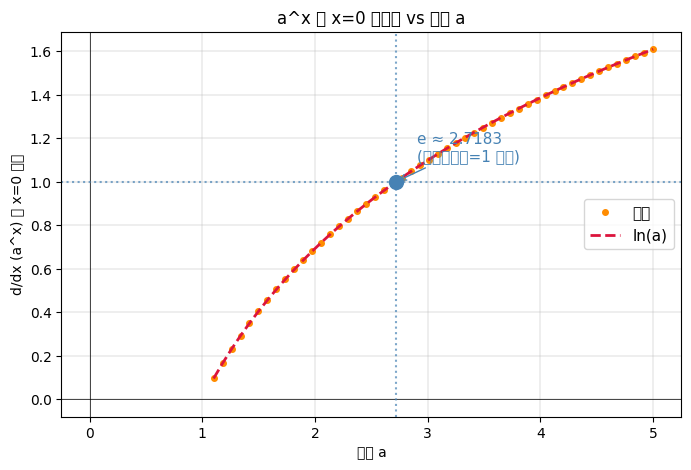

In [3]:
# === 實驗 2：常數 vs 底數的關係 ===
bases = np.linspace(1.1, 5.0, 50)
constants = []
for a in bases:
    # 在 x=0 處算 a^x 的導數，就是常數本身
    numeric = central_diff(lambda x, a=a: a ** x, 0.0)
    constants.append(numeric)

constants = np.array(constants)

fig, ax = plt.subplots(figsize=(8, 5))
setup_ax(ax, title="a^x 在 x=0 的導數 vs 底數 a")
ax.plot(bases, constants, "o", color="darkorange", markersize=4, label="數值")
ax.plot(bases, np.log(bases), "--", color="crimson", linewidth=2, label="ln(a)")

# 標出 e
e = np.e
ax.axvline(e, color="steelblue", linestyle=":", alpha=0.7)
ax.axhline(1.0, color="steelblue", linestyle=":", alpha=0.7)
ax.plot(e, 1.0, "o", color="steelblue", markersize=10, zorder=5)
ax.annotate(f"e ≈ {e:.4f}\n(那個讓常數=1 的底)",
            (e, 1.0), xytext=(15, 15),
            textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="steelblue"),
            fontsize=11, color="steelblue")

ax.set_xlabel("底數 a")
ax.set_ylabel("d/dx (a^x) 在 x=0 的值")
ax.legend(fontsize=11)
plt.show()

## Part 3：自己「發現」$e$——讓常數 = 1 的那個底

### 數學家的偷懶哲學

對任何 $a$，$\frac{d}{dx} a^x = a^x \cdot \ln(a)$ 這個式子裡有個礙眼的 $\ln(a)$。我們會想：「**有沒有一個底，能讓這個常數變成 1？**」

如果有，那個底滿足 $\ln(a) = 1$，也就是

$$a = e$$

### 用二分搜尋找 e

我們不假設知道 $e$，只用「常數 = 1」這個條件來找它。

In [4]:
# === 實驗 3：用二分搜尋發現 e ===
# 目標：找出讓 a^x 在 x=0 的導數 = 1 的那個 a

lo, hi = 2.0, 3.0  # 我們知道 2 太小（const ≈ 0.69），3 太大（const ≈ 1.10）
for step in range(40):
    mid = (lo + hi) / 2
    const_mid = central_diff(lambda x, a=mid: a ** x, 0.0)
    if const_mid < 1.0:
        lo = mid
    else:
        hi = mid

discovered_e = (lo + hi) / 2
print(f"二分搜尋找到的 e = {discovered_e:.12f}")
print(f"NumPy 給的 e     = {np.e:.12f}")
print(f"誤差              = {abs(discovered_e - np.e):.2e}")
print()

# 確認：e^x 在 x=0 的導數確實是 1
print(f"d/dx (e^x) 在 x=0 = {central_diff(np.exp, 0.0):.10f}  ← 1 ✓")

二分搜尋找到的 e = 2.718281828402
NumPy 給的 e     = 2.718281828459
誤差              = 5.68e-11

d/dx (e^x) 在 x=0 = 1.0000000000  ← 1 ✓


這就是 $e$ 的「**操作型定義**」：

> $e$ 是那個唯一的底數，使得 $a^x$ 的圖形在每一點上**斜率等於高度**。

換句話說：

$$\boxed{\frac{d}{dx} e^x = e^x}$$

這是整個微積分裡最特別的一個函數——**它是自己的導數**。

## Part 4：用鏈式法則延伸

### 一般化

對任何 $f(x)$：

$$\frac{d}{dx} e^{f(x)} = e^{f(x)} \cdot f'(x)$$

特例：

| 函數 | 導數 |
|---|---|
| $e^{kx}$ | $k\, e^{kx}$ |
| $e^{x^2}$ | $2x\, e^{x^2}$ |
| $e^{-x^2/2}$（高斯鐘形） | $-x\, e^{-x^2/2}$ |
| $a^x = e^{x \ln a}$ | $\ln(a) \cdot a^x$  ← 把 $a^x$ 寫成 $e^{x\ln a}$ 就回到這條公式 |

### 為什麼把所有指數都寫成 $e$ 為底？

因為這樣求導**只剩 $e$ 一個單純規則**。$\ln(a)$ 不再是「神秘常數」，而是**鏈式法則自動產生**的內層導數 $\frac{d}{dx}(x \ln a) = \ln a$。

In [5]:
# === 實驗 4：鏈式法則 + 指數函數 ===
test_cases = [
    ("e^(2x)",     lambda x: np.exp(2*x),         lambda x: 2 * np.exp(2*x)),
    ("e^(x²)",     lambda x: np.exp(x**2),        lambda x: 2*x * np.exp(x**2)),
    ("e^(-x²/2)",  lambda x: np.exp(-x**2/2),     lambda x: -x * np.exp(-x**2/2)),
    ("3^x",        lambda x: 3.0**x,              lambda x: np.log(3) * 3.0**x),
]

x0 = 0.7
print(f"在 x = {x0}：")
print(f"{'函數':<12} | {'數值':>14} | {'解析':>14} | {'誤差':>10}")
print("-" * 60)
for name, fn, dfn in test_cases:
    n = central_diff(fn, x0)
    a = dfn(x0)
    print(f"{name:<12} | {n:>14.6f} | {a:>14.6f} | {abs(n-a):>10.2e}")

在 x = 0.7：
函數           |             數值 |             解析 |         誤差
------------------------------------------------------------
e^(2x)       |       8.110400 |       8.110400 |   4.91e-10
e^(x²)       |       2.285243 |       2.285243 |   2.85e-10
e^(-x²/2)    |      -0.547893 |      -0.547893 |   2.49e-11
3^x          |       2.370442 |       2.370442 |   3.77e-11


## Part 5：視覺化——斜率 = 高度

把 $e^x$ 畫出來，在好幾個點上畫切線，你會看到 **每一點的切線斜率正好等於該點的函數值**。

/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 40670 (\N{CJK UNIFIED IDEOGRAPH-9EDE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserW

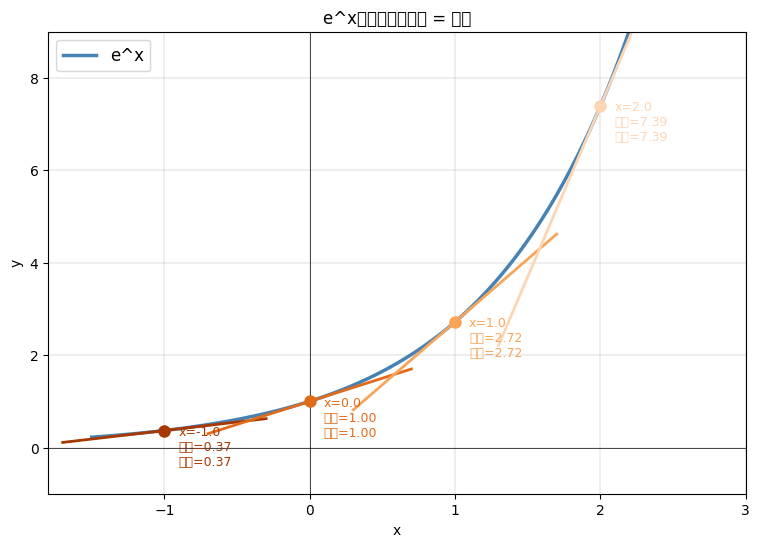

In [6]:
# === 實驗 5：斜率 = 高度 視覺化 ===
xs = np.linspace(-1.5, 2.5, 300)
ys = np.exp(xs)

fig, ax = plt.subplots(figsize=(9, 6))
setup_ax(ax, title="e^x：每一點的斜率 = 高度")
ax.plot(xs, ys, color="steelblue", linewidth=2.5, label="e^x")

tangent_points = [-1.0, 0.0, 1.0, 2.0]
colors = ["#a83800", "#e26b1a", "#f8a55a", "#fcd5b4"]

for x0, col in zip(tangent_points, colors):
    y0 = np.exp(x0)
    slope = y0  # 因為導數 = 函數本身
    # 切線：y = y0 + slope·(x - x0)
    line_x = np.linspace(x0 - 0.7, x0 + 0.7, 30)
    line_y = y0 + slope * (line_x - x0)
    ax.plot(line_x, line_y, "-", color=col, linewidth=2)
    ax.plot(x0, y0, "o", color=col, markersize=8, zorder=5)
    ax.annotate(f"x={x0}\n高度={y0:.2f}\n斜率={slope:.2f}",
                (x0, y0), xytext=(10, -25),
                textcoords="offset points", fontsize=9, color=col)

ax.set_xlim(-1.8, 3)
ax.set_ylim(-1, 9)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=12, loc="upper left")
plt.show()

這張圖才是 $e$ 真正特別的地方——**沒有別的函數有「斜率 = 高度」這個性質**（除了 $C \cdot e^x$ 這種常數倍）。所有「描述自我增殖過程」的微分方程，例如人口、利息、放射性衰變、神經網路梯度的指數衰退，都會自然地引出 $e$。

## Part 6：為什麼 DL 到處都是 $e$？

### Sigmoid

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

它的導數有個漂亮的性質：

$$\sigma'(x) = \sigma(x)\,(1 - \sigma(x))$$

意思是：**算完前向傳播，反向傳播完全免費**——不需要重新算 $e^{-x}$，直接拿 $\sigma(x)$ 自己就能算出梯度。這個性質直接來自 $\frac{d}{dx} e^{-x} = -e^{-x}$。

### Softmax

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

為什麼用 $e^{z_i}$ 而不是別的？兩個原因：
1. **保證正數**——機率不能是負的
2. **指數放大差距**——大的更大、小的更小，做出「鋒利」的分布

### Cross-entropy / Log-likelihood

$$\mathcal{L} = -\log p(y \mid x)$$

當 $p$ 來自 softmax，$\log p = z_y - \log \sum_j e^{z_j}$。$\log$ 和 $e$ 是逆運算，**它們組合起來把連乘變成連加**——這對訓練的數值穩定性極為關鍵。

下面看一下 sigmoid。

/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_65536/627495097.py:25: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_65536/627495097.py:25: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_65536/627495097.py:25: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_65536/627495097.py:25: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/johnny/lab/dl-notes/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io

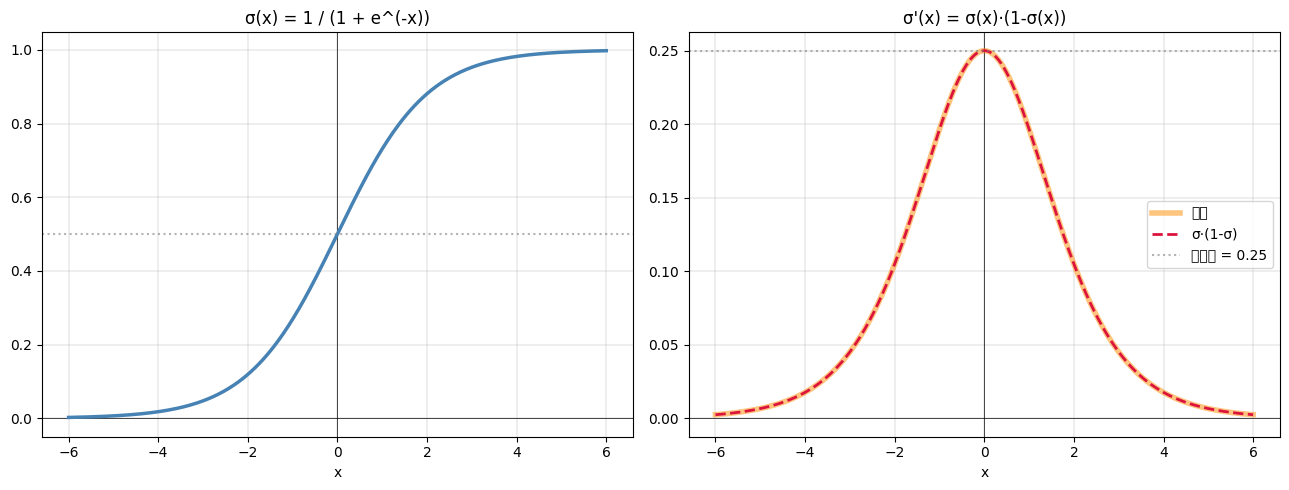

σ'(x) 的最大值 = 0.2500 （在 x=0 處）
這就是 Ch 4 提到的『sigmoid 連乘 N 次最多 0.25^N，深度網路梯度消失』的根源


In [7]:
# === 實驗 6：sigmoid 與它的導數 ===
def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))

xs = np.linspace(-6, 6, 400)
ss = sigmoid(xs)
ds_analytic  = ss * (1 - ss)               # σ(x)·(1-σ(x))
ds_numeric   = np.gradient(ss, xs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

setup_ax(axes[0], title="σ(x) = 1 / (1 + e^(-x))")
axes[0].plot(xs, ss, color="steelblue", linewidth=2.5)
axes[0].axhline(0.5, color="gray", linestyle=":", alpha=0.6)
axes[0].set_xlabel("x")

setup_ax(axes[1], title="σ'(x) = σ(x)·(1-σ(x))")
axes[1].plot(xs, ds_numeric, color="darkorange", linewidth=4, alpha=0.5,
             label="數值")
axes[1].plot(xs, ds_analytic, "--", color="crimson", linewidth=2,
             label="σ·(1-σ)")
axes[1].axhline(0.25, color="gray", linestyle=":", alpha=0.6,
                label="最大值 = 0.25")
axes[1].set_xlabel("x")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"σ'(x) 的最大值 = {ds_analytic.max():.4f} （在 x=0 處）")
print(f"這就是 Ch 4 提到的『sigmoid 連乘 N 次最多 0.25^N，深度網路梯度消失』的根源")

## Part 7：練習區 🏋️

幾個小挑戰：

1. 對 $f(x) = e^{-x^2}$（高斯鐘形）畫圖 + 它的導數，觀察極值點在哪裡
2. 對 $f(x) = x \cdot e^{-x}$（gamma-like），找它的最大值（用 $f'(x) = 0$）
3. 寫 softmax，驗證輸出加總 = 1，看看放大效果

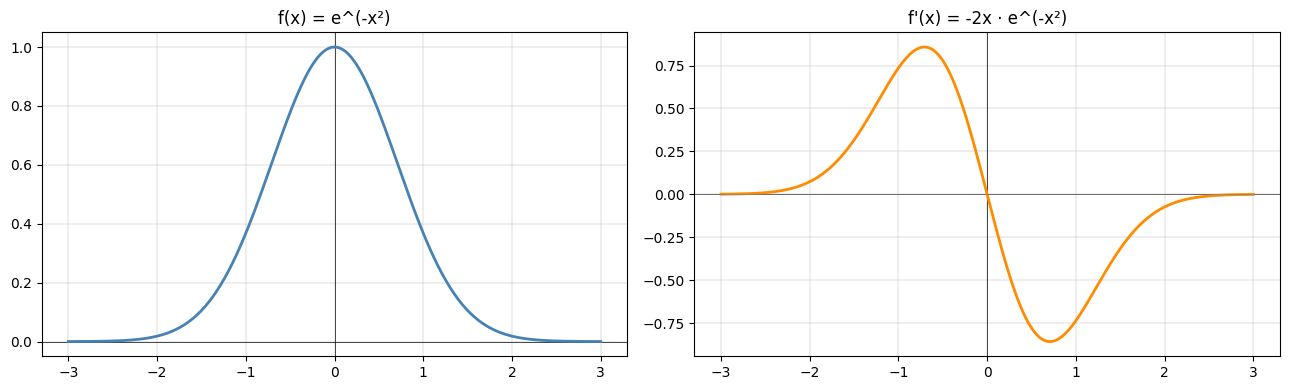

極值在 x=0（f'=0），是最大值。


In [8]:
# ===== 練習 1：高斯鐘形 =====
def gauss(x): return np.exp(-x ** 2)
xs = np.linspace(-3, 3, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
setup_ax(axes[0], title="f(x) = e^(-x²)")
axes[0].plot(xs, gauss(xs), color="steelblue", linewidth=2)
setup_ax(axes[1], title="f'(x) = -2x · e^(-x²)")
axes[1].plot(xs, np.gradient(gauss(xs), xs), color="darkorange", linewidth=2)
axes[1].axhline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()
print("極值在 x=0（f'=0），是最大值。")

數值找到的最大點：x ≈ 1.0025, f(x) ≈ 0.3679
解析：x = 1, f(1) = 1/e = 0.3679


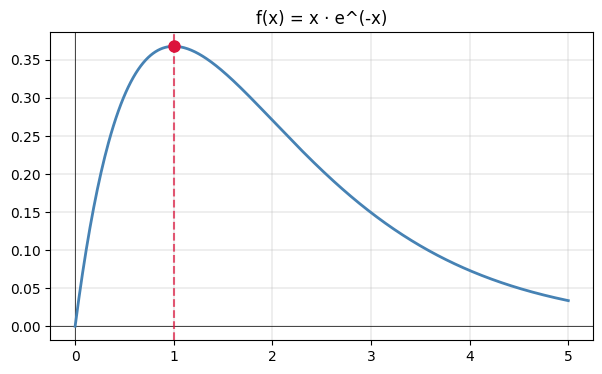

In [9]:
# ===== 練習 2：x·e^(-x) 的最大值 =====
# 解析：f'(x) = e^(-x) - x·e^(-x) = (1-x)·e^(-x)，所以 f'(x)=0 → x=1
def f3(x): return x * np.exp(-x)

xs = np.linspace(0, 5, 400)
ys = f3(xs)
ds = np.gradient(ys, xs)

# 找 f' ≈ 0 的位置
zero_idx = np.argmin(np.abs(ds))
print(f"數值找到的最大點：x ≈ {xs[zero_idx]:.4f}, f(x) ≈ {ys[zero_idx]:.4f}")
print(f"解析：x = 1, f(1) = 1/e = {1/np.e:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
setup_ax(ax, title="f(x) = x · e^(-x)")
ax.plot(xs, ys, color="steelblue", linewidth=2)
ax.axvline(xs[zero_idx], color="crimson", linestyle="--", alpha=0.7)
ax.plot(xs[zero_idx], ys[zero_idx], "o", color="crimson", markersize=8)
plt.show()

In [10]:
# ===== 練習 3：softmax 放大效果 =====
def softmax(z, T=1.0):
    """加 temperature T：T 越小越尖銳，T 越大越平滑。"""
    z = np.asarray(z) / T
    z = z - z.max()  # 數值穩定性技巧：減最大值不改變結果
    e = np.exp(z)
    return e / e.sum()

logits = np.array([1.0, 2.0, 3.0, 1.5])
print(f"logits = {logits}")
for T in [2.0, 1.0, 0.5, 0.1]:
    probs = softmax(logits, T=T)
    print(f"  T={T:>4}: {np.round(probs, 4)}  sum={probs.sum():.4f}")
print()
print("觀察：T → 0 時，所有機率集中到最大那個 logit；T → ∞ 時趨近均勻分布。")

logits = [1.  2.  3.  1.5]
  T= 2.0: [0.1504 0.2479 0.4087 0.1931]  sum=1.0000
  T= 1.0: [0.0784 0.2131 0.5793 0.1293]  sum=1.0000
  T= 0.5: [0.0152 0.1125 0.831  0.0414]  sum=1.0000
  T= 0.1: [0. 0. 1. 0.]  sum=1.0000

觀察：T → 0 時，所有機率集中到最大那個 logit；T → ∞ 時趨近均勻分布。


## Part 8：總結 & 深度學習連結

### 微積分這一章帶走的事

| 概念 | 一句話 |
|---|---|
| $\frac{d}{dx} a^x = a^x \ln(a)$ | 任何指數函數的導數，就是它本身 × $\ln(a)$ |
| $e$ 的「操作型」定義 | 唯一讓「$a^x$ 斜率 = 高度」成立的那個底 |
| $\frac{d}{dx} e^x = e^x$ | $e^x$ 是自己的導數——**獨一無二** |
| $\frac{d}{dx} e^{f(x)} = e^{f(x)} f'(x)$ | 鏈式法則 + 指數，能搞定任何 exp 組合 |

<br>

### 連到深度學習

| 微積分 | DL 對應 |
|---|---|
| $e^x$ 自己微分還是自己 | sigmoid 導數 $\sigma'=\sigma(1-\sigma)$，**反向傳播零成本** |
| $e^x$ 永遠正 | softmax 用 $e^{z_i}$ 強迫輸出非負，自然形成機率 |
| $\log$ 和 $e$ 是逆 | log-likelihood 把連乘 $\prod p_i$ 變連加 $\sum \log p_i$，數值穩定 |
| $e^{-x^2/2}$ 的導數 | 高斯分布的 score function，是 diffusion model 的核心 |
| $\sigma'(x) \le 0.25$ | **梯度消失**的數學根源（連乘 N 次） |

<br>

### 一個值得記住的事實

3B1B 在影片裡說的金句：

> **「自然界對指數函數的偏愛，不是任意的。它源自於『變化率正比於當前量』這件事——而 $e$ 就是這個『正比』的標準刻度。」**

DL 裡的 sigmoid、softmax、Adam 的指數平均、學習率衰減、注意力分數的 softmax 溫度⋯⋯都是這同一個東西的不同面向。

<br>

### 下一步

- **Ch 6 隱函數求導**：當 $y$ 沒有顯式的 $y = f(x)$ 形式（例如 $x^2 + y^2 = 1$）怎麼辦
- **Ch 7 極限**：$\epsilon$-$\delta$ 嚴格化所有「$h \to 0$」的論證
- **Ch 11 泰勒級數**：把任何函數展成多項式——**Adam、牛頓法、二階優化的數學基礎**